In [9]:
import numpy as np
np.random.seed(42)

In [10]:
X = np.random.randn(3, 4)
print("X =")
print(X)

X =
[[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]]


In [11]:
Y = np.ones((4, 2))
print("Y =")
print(Y)

Y =
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]


In [12]:
Z = X @ Y
print("Z =")
print(Z)

Z =
[[ 2.52916825  2.52916825]
 [ 1.87835721  1.87835721]
 [-0.85606179 -0.85606179]]


In [13]:
element_row1_col2 = Z[0, 1]
row2_all = Z[1, :]
print(f"第一行第二列: {element_row1_col2}")
print(f"第二行: {row2_all}")

第一行第二列: 2.5291682463487657
第二行: [1.87835721 1.87835721]


In [14]:
fro_norm = np.linalg.norm(Z, 'fro')
print(f"Frobenius 范数: {fro_norm}")

Frobenius 范数: 4.616873319476863


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

print("库导入成功！")

库导入成功！


In [16]:
# 设置参数
n = 10000  # 每次抽取的样本量
m = 1000   # 重复次数

# 存储样本均值的数组
sample_means = np.zeros(m)

# 模拟中心极限定理
print("正在模拟，请稍候...")
for i in range(m):
    # 生成 n 个服从 U(0,1) 的随机变量
    samples = np.random.uniform(0, 1, n)
    # 计算均值并存储
    sample_means[i] = np.mean(samples)

print(f"模拟完成！")
print(f"生成了 {m} 个样本均值")
print(f"前5个均值: {sample_means[:5]}")

正在模拟，请稍候...
模拟完成！
生成了 1000 个样本均值
前5个均值: [0.49424173 0.50441825 0.50031825 0.49835874 0.49705027]


In [17]:
# 计算这些均值的实际均值和方差
actual_mean = np.mean(sample_means)
actual_variance = np.var(sample_means, ddof=0)  # 总体方差

# 理论值
theoretical_mean = 0.5  # U(0,1)的总体均值
theoretical_variance = (1/12) / n  # U(0,1)的方差是1/12，样本均值的方差是σ²/n

print("="*50)
print("统计结果：")
print("="*50)
print(f"实际样本均值的均值: {actual_mean:.6f}")
print(f"理论总体均值: {theoretical_mean}")
print(f"\n实际样本均值的方差: {actual_variance:.8f}")
print(f"理论样本均值的方差 (σ²/n): {theoretical_variance:.8f}")
print(f"\n两者相对误差: {abs(actual_variance - theoretical_variance)/theoretical_variance*100:.2f}%")

统计结果：
实际样本均值的均值: 0.499993
理论总体均值: 0.5

实际样本均值的方差: 0.00000831
理论样本均值的方差 (σ²/n): 0.00000833

两者相对误差: 0.23%


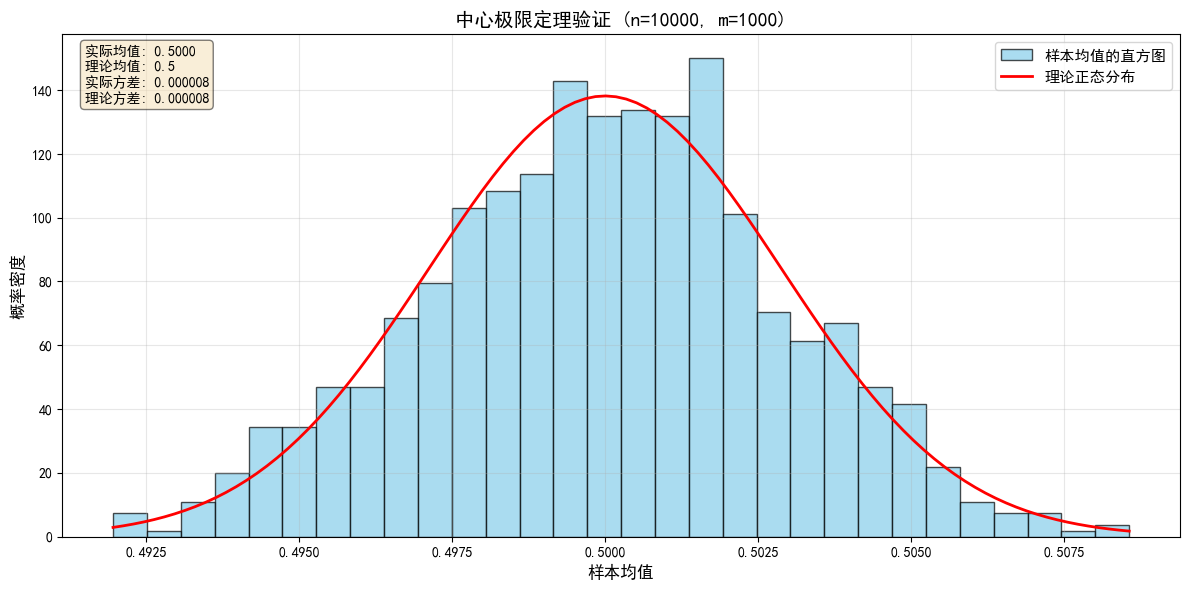

In [18]:
# 创建图形
fig, ax = plt.subplots(figsize=(12, 6))

# 绘制直方图
count, bins, patches = ax.hist(sample_means, bins=30, density=True, 
                                alpha=0.7, color='skyblue', edgecolor='black', 
                                label='样本均值的直方图')

# 绘制理论正态分布曲线
x = np.linspace(min(sample_means), max(sample_means), 100)
# 理论分布：N(μ, σ²/n)，其中μ=0.5，σ²=1/12
theoretical_pdf = stats.norm.pdf(x, loc=0.5, scale=np.sqrt(1/12/n))
ax.plot(x, theoretical_pdf, 'r-', linewidth=2, label='理论正态分布')

# 添加标准正态分布的Q-Q图验证（可选）
ax.set_xlabel('样本均值', fontsize=12)
ax.set_ylabel('概率密度', fontsize=12)
ax.set_title(f'中心极限定理验证 (n={n}, m={m})', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# 添加统计信息文本框
stats_text = f'实际均值: {actual_mean:.4f}\n理论均值: 0.5\n实际方差: {actual_variance:.6f}\n理论方差: {theoretical_variance:.6f}'
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

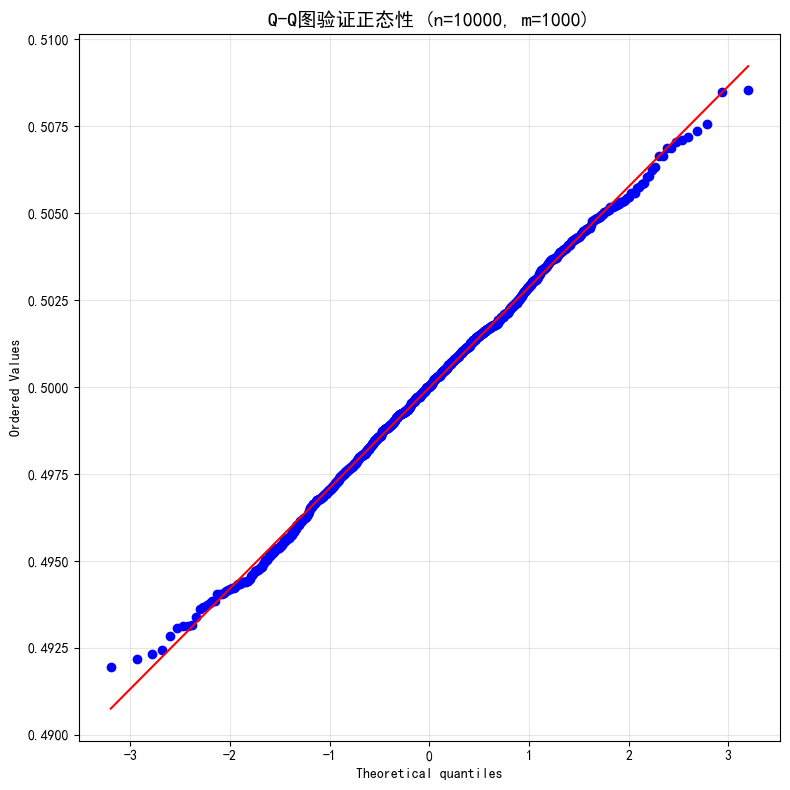

Shapiro-Wilk正态性检验:
统计量: 0.9980
p值: 0.2992
结论: 数据符合正态分布 (p > 0.05)


In [19]:
# Q-Q图验证样本均值的正态性
fig, ax = plt.subplots(figsize=(8, 8))

# 生成Q-Q图
stats.probplot(sample_means, dist="norm", plot=ax)
ax.set_title(f'Q-Q图验证正态性 (n={n}, m={m})', fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 正态性检验（Shapiro-Wilk检验）
from scipy.stats import shapiro
statistic, p_value = shapiro(sample_means[:5000])  # Shapiro检验限制样本量≤5000
print(f"Shapiro-Wilk正态性检验:")
print(f"统计量: {statistic:.4f}")
print(f"p值: {p_value:.4f}")
if p_value > 0.05:
    print("结论: 数据符合正态分布 (p > 0.05)")
else:
    print("结论: 数据不符合正态分布 (p < 0.05)，但大样本下CLT仍然近似成立")

In [20]:
import numpy as np

print("="*60)
print("手动实现计算图的反向传播")
print("="*60)

# 给定参数
x = 2.0
w1 = 1.5
w2 = 0.5

print(f"\n输入参数:")
print(f"x = {x}")
print(f"w1 = {w1}")
print(f"w2 = {w2}")

# ========== 手动前向传播 ==========
print("\n" + "="*60)
print("1. 手动前向传播")
print("="*60)

# 前向计算
a = x * w1
b = a + w2
L = b ** 2  # L = b^2

print(f"a = x · w1 = {x} × {w1} = {a}")
print(f"b = a + w2 = {a} + {w2} = {b}")
print(f"L = b² = {b}² = {L}")

# ========== 手动反向传播（链式法则）==========
print("\n" + "="*60)
print("2. 手动反向传播（链式法则）")
print("="*60)

# 计算梯度
# dL/db = 2b
dL_db = 2 * b
print(f"∂L/∂b = 2b = 2 × {b} = {dL_db}")

# db/da = 1
db_da = 1
print(f"∂b/∂a = 1")

# da/dw1 = x
da_dw1 = x
print(f"∂a/∂w1 = x = {x}")

# 链式法则求梯度
# dL/dw1 = dL/db * db/da * da/dw1
dL_dw1 = dL_db * db_da * da_dw1
print(f"\n∂L/∂w1 = ∂L/∂b × ∂b/∂a × ∂a/∂w1")
print(f"       = {dL_db} × {db_da} × {da_dw1}")
print(f"       = {dL_dw1}")

# dL/dw2 = dL/db * db/dw2
db_dw2 = 1  # b = a + w2, 所以 db/dw2 = 1
dL_dw2 = dL_db * db_dw2
print(f"\n∂L/∂w2 = ∂L/∂b × ∂b/∂w2")
print(f"       = {dL_db} × {db_dw2}")
print(f"       = {dL_dw2}")

print(f"\n最终梯度结果:")
print(f"∂L/∂w1 = {dL_dw1}")
print(f"∂L/∂w2 = {dL_dw2}")

手动实现计算图的反向传播

输入参数:
x = 2.0
w1 = 1.5
w2 = 0.5

1. 手动前向传播
a = x · w1 = 2.0 × 1.5 = 3.0
b = a + w2 = 3.0 + 0.5 = 3.5
L = b² = 3.5² = 12.25

2. 手动反向传播（链式法则）
∂L/∂b = 2b = 2 × 3.5 = 7.0
∂b/∂a = 1
∂a/∂w1 = x = 2.0

∂L/∂w1 = ∂L/∂b × ∂b/∂a × ∂a/∂w1
       = 7.0 × 1 × 2.0
       = 14.0

∂L/∂w2 = ∂L/∂b × ∂b/∂w2
       = 7.0 × 1
       = 7.0

最终梯度结果:
∂L/∂w1 = 14.0
∂L/∂w2 = 7.0


In [21]:
print("\n" + "="*60)
print("3. 数值微分验证（梯度检查）")
print("="*60)

def numerical_gradient(func, params, param_name, epsilon=1e-5):
    """数值方法计算梯度（中心差分）"""
    original_value = params[param_name]
    
    # 正向扰动
    params[param_name] = original_value + epsilon
    forward_loss = func(params)
    
    # 负向扰动
    params[param_name] = original_value - epsilon
    backward_loss = func(params)
    
    # 恢复原值
    params[param_name] = original_value
    
    # 中心差分公式
    gradient = (forward_loss - backward_loss) / (2 * epsilon)
    return gradient

# 定义损失函数
def loss_function(params):
    x = params['x']
    w1 = params['w1']
    w2 = params['w2']
    a = x * w1
    b = a + w2
    L = b ** 2
    return L

# 参数
params = {
    'x': 2.0,
    'w1': 1.5,
    'w2': 0.5
}

# 计算数值梯度
num_grad_w1 = numerical_gradient(loss_function, params, 'w1')
num_grad_w2 = numerical_gradient(loss_function, params, 'w2')

print(f"数值微分计算结果:")
print(f"∂L/∂w1 = {num_grad_w1:.10f}")
print(f"∂L/∂w2 = {num_grad_w2:.10f}")


3. 数值微分验证（梯度检查）
数值微分计算结果:
∂L/∂w1 = 14.0000000001
∂L/∂w2 = 7.0000000001


In [22]:
print("\n" + "="*60)
print("4. 结果验证与对比")
print("="*60)

print(f"\n{'方法':<15} {'∂L/∂w1':<18} {'∂L/∂w2':<18} {'是否一致':<10}")
print("-"*65)
print(f"{'手动链式法则':<15} {dL_dw1:<18.10f} {dL_dw2:<18.10f} {'':<10}")
print(f"{'数值微分':<15} {num_grad_w1:<18.10f} {num_grad_w2:<18.10f} {'':<10}")

# 验证一致性
tol = 1e-6
w1_match = abs(dL_dw1 - num_grad_w1) < tol
w2_match = abs(dL_dw2 - num_grad_w2) < tol

print(f"\n误差分析:")
print(f"∂L/∂w1 误差: {abs(dL_dw1 - num_grad_w1):.2e}")
print(f"∂L/∂w2 误差: {abs(dL_dw2 - num_grad_w2):.2e}")

if w1_match and w2_match:
    print(f"\n✓ 验证成功！手动链式法则与数值微分结果完全一致！")
    print("  证明了反向传播计算的正确性。")
else:
    print(f"\n✗ 结果不一致，请检查计算。")


4. 结果验证与对比

方法              ∂L/∂w1             ∂L/∂w2             是否一致      
-----------------------------------------------------------------
手动链式法则          14.0000000000      7.0000000000                 
数值微分            14.0000000001      7.0000000001                 

误差分析:
∂L/∂w1 误差: 9.17e-11
∂L/∂w2 误差: 9.03e-11

✓ 验证成功！手动链式法则与数值微分结果完全一致！
  证明了反向传播计算的正确性。


从零实现 Softmax 回归 - MNIST 手写数字分类

数据集信息:
样本数量: 1797
特征维度: 64 (8×8 图像展平)
类别数量: 10 (数字 0-9)
标签范围: 0 - 9


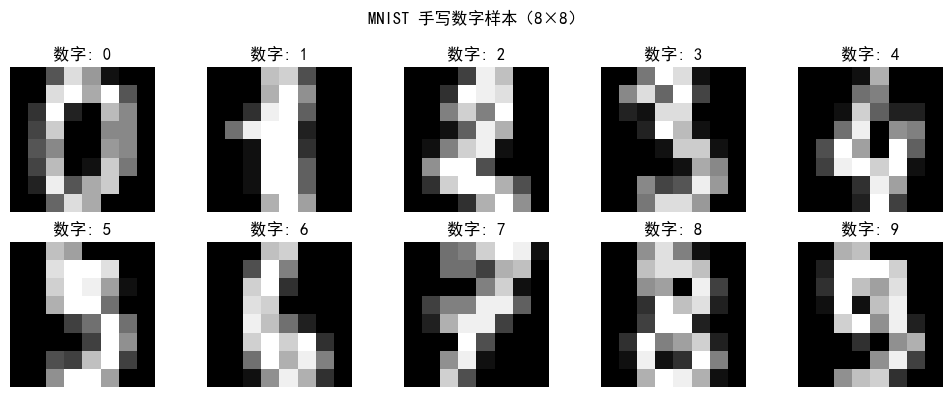

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 设置随机种子
np.random.seed(42)

print("="*60)
print("从零实现 Softmax 回归 - MNIST 手写数字分类")
print("="*60)

# 加载数据
digits = load_digits()
X = digits.data  # 特征 (1797, 64)
y = digits.target  # 标签 (1797,)

print(f"\n数据集信息:")
print(f"样本数量: {X.shape[0]}")
print(f"特征维度: {X.shape[1]} (8×8 图像展平)")
print(f"类别数量: {len(np.unique(y))} (数字 0-9)")
print(f"标签范围: {np.min(y)} - {np.max(y)}")

# 显示部分样本
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f'数字: {y[i]}')
    ax.axis('off')
plt.suptitle('MNIST 手写数字样本（8×8）')
plt.tight_layout()
plt.show()

In [24]:
# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n数据划分:")
print(f"训练集大小: {X_train.shape[0]}")
print(f"测试集大小: {X_test.shape[0]}")

# 标准化（提高训练稳定性）
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"\n特征标准化完成")
print(f"训练集均值: {X_train.mean():.3f}, 标准差: {X_train.std():.3f}")
print(f"测试集均值: {X_test.mean():.3f}, 标准差: {X_test.std():.3f}")

# One-hot 编码函数
def one_hot_encoding(y, num_classes=10):
    """将标签转换为 one-hot 编码"""
    n_samples = len(y)
    y_one_hot = np.zeros((n_samples, num_classes))
    y_one_hot[np.arange(n_samples), y] = 1
    return y_one_hot

# 转换标签
y_train_one_hot = one_hot_encoding(y_train)
y_test_one_hot = one_hot_encoding(y_test)

print(f"\nOne-hot 编码后:")
print(f"训练集标签形状: {y_train_one_hot.shape}")
print(f"第一个样本的 one-hot: {y_train_one_hot[0]}")
print(f"对应的数字: {y_train[0]}")


数据划分:
训练集大小: 1437
测试集大小: 360

特征标准化完成
训练集均值: 0.000, 标准差: 0.976
测试集均值: -0.004, 标准差: 1.103

One-hot 编码后:
训练集标签形状: (1437, 10)
第一个样本的 one-hot: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
对应的数字: 5


In [25]:
class SoftmaxRegression:
    """从零实现的 Softmax 回归分类器"""
    
    def __init__(self, input_dim, num_classes, learning_rate=0.1):
        """
        初始化参数
        input_dim: 输入特征维度 (64)
        num_classes: 类别数量 (10)
        learning_rate: 学习率
        """
        self.input_dim = input_dim
        self.num_classes = num_classes
        self.learning_rate = learning_rate
        
        # 初始化权重和偏置（小随机数）
        self.W = np.random.randn(input_dim, num_classes) * 0.01
        self.b = np.zeros((1, num_classes))
        
    def softmax(self, z):
        """
        Softmax 函数
        将 logits 转换为概率分布
        """
        # 数值稳定性：减去最大值
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)
    
    def forward(self, X):
        """
        前向传播
        X: (n_samples, input_dim)
        返回: 每个类别的概率 (n_samples, num_classes)
        """
        # 线性变换: z = X·W + b
        z = np.dot(X, self.W) + self.b
        # Softmax 激活
        return self.softmax(z)
    
    def cross_entropy_loss(self, y_pred, y_true):
        """
        交叉熵损失函数
        y_pred: 预测概率 (n_samples, num_classes)
        y_true: one-hot 标签 (n_samples, num_classes)
        返回: 平均损失
        """
        n_samples = y_pred.shape[0]
        # 避免 log(0)
        eps = 1e-8
        loss = -np.sum(y_true * np.log(y_pred + eps)) / n_samples
        return loss
    
    def compute_gradients(self, X, y_pred, y_true):
        """
        计算梯度
        X: 输入特征 (n_samples, input_dim)
        y_pred: 预测概率 (n_samples, num_classes)
        y_true: one-hot 标签 (n_samples, num_classes)
        """
        n_samples = X.shape[0]
        
        # 梯度计算
        # dL/dz = y_pred - y_true
        dz = y_pred - y_true
        
        # dL/dW = X^T · dz
        dW = np.dot(X.T, dz) / n_samples
        
        # dL/db = sum(dz) / n_samples
        db = np.sum(dz, axis=0, keepdims=True) / n_samples
        
        return dW, db
    
    def update_parameters(self, dW, db):
        """使用梯度下降更新参数"""
        self.W -= self.learning_rate * dW
        self.b -= self.learning_rate * db
    
    def train_batch(self, X_batch, y_batch):
        """训练一个批次"""
        # 前向传播
        y_pred = self.forward(X_batch)
        
        # 计算损失
        loss = self.cross_entropy_loss(y_pred, y_batch)
        
        # 计算梯度
        dW, db = self.compute_gradients(X_batch, y_pred, y_batch)
        
        # 更新参数
        self.update_parameters(dW, db)
        
        return loss
    
    def predict(self, X):
        """预测类别"""
        y_pred = self.forward(X)
        return np.argmax(y_pred, axis=1)
    
    def accuracy(self, X, y):
        """计算准确率"""
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

# 创建模型
model = SoftmaxRegression(
    input_dim=X_train.shape[1], 
    num_classes=10, 
    learning_rate=0.1
)

print("Softmax 回归模型创建成功！")
print(f"输入维度: {model.input_dim}")
print(f"输出类别: {model.num_classes}")
print(f"学习率: {model.learning_rate}")
print(f"权重形状: {model.W.shape}")
print(f"偏置形状: {model.b.shape}")

Softmax 回归模型创建成功！
输入维度: 64
输出类别: 10
学习率: 0.1
权重形状: (64, 10)
偏置形状: (1, 10)


In [26]:
# 训练参数
batch_size = 32
epochs = 50
n_samples = X_train.shape[0]
n_batches = int(np.ceil(n_samples / batch_size))

# 记录训练历史
train_losses = []
train_accuracies = []
test_accuracies = []

print("="*60)
print("开始训练")
print("="*60)
print(f"批次大小: {batch_size}")
print(f"训练轮数: {epochs}")
print(f"每轮批次数: {n_batches}")
print("-"*60)

for epoch in range(epochs):
    # 打乱训练数据
    indices = np.random.permutation(n_samples)
    X_shuffled = X_train[indices]
    y_shuffled = y_train_one_hot[indices]
    
    epoch_loss = 0
    
    # 小批量训练
    for batch_idx in range(n_batches):
        start_idx = batch_idx * batch_size
        end_idx = min(start_idx + batch_size, n_samples)
        
        X_batch = X_shuffled[start_idx:end_idx]
        y_batch = y_shuffled[start_idx:end_idx]
        
        loss = model.train_batch(X_batch, y_batch)
        epoch_loss += loss
    
    # 平均损失
    avg_loss = epoch_loss / n_batches
    
    # 计算准确率
    train_acc = model.accuracy(X_train, y_train)
    test_acc = model.accuracy(X_test, y_test)
    
    # 记录历史
    train_losses.append(avg_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    
    # 打印进度
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}/{epochs} | "
              f"Loss: {avg_loss:.4f} | "
              f"Train Acc: {train_acc:.4f} | "
              f"Test Acc: {test_acc:.4f}")

print("-"*60)
print("训练完成！")

开始训练
批次大小: 32
训练轮数: 50
每轮批次数: 45
------------------------------------------------------------
Epoch   5/50 | Loss: 0.2008 | Train Acc: 0.9687 | Test Acc: 0.9444
Epoch  10/50 | Loss: 0.1340 | Train Acc: 0.9798 | Test Acc: 0.9500
Epoch  15/50 | Loss: 0.1060 | Train Acc: 0.9847 | Test Acc: 0.9556
Epoch  20/50 | Loss: 0.0894 | Train Acc: 0.9889 | Test Acc: 0.9639
Epoch  25/50 | Loss: 0.0780 | Train Acc: 0.9889 | Test Acc: 0.9639
Epoch  30/50 | Loss: 0.0698 | Train Acc: 0.9903 | Test Acc: 0.9639
Epoch  35/50 | Loss: 0.0634 | Train Acc: 0.9937 | Test Acc: 0.9639
Epoch  40/50 | Loss: 0.0582 | Train Acc: 0.9951 | Test Acc: 0.9639
Epoch  45/50 | Loss: 0.0540 | Train Acc: 0.9958 | Test Acc: 0.9667
Epoch  50/50 | Loss: 0.0505 | Train Acc: 0.9958 | Test Acc: 0.9667
------------------------------------------------------------
训练完成！


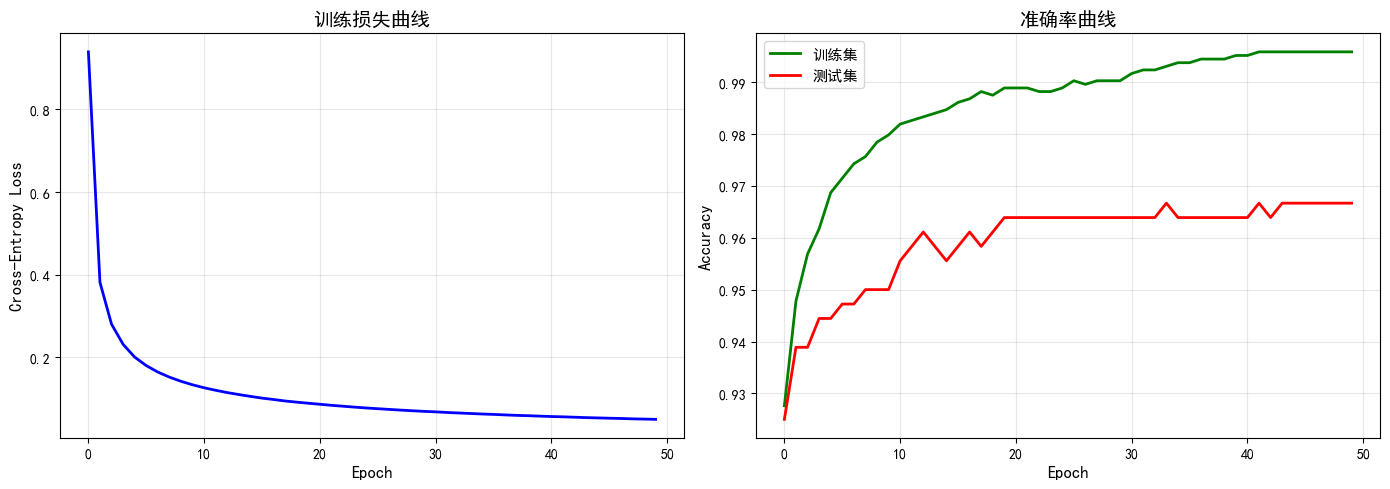


最终结果
训练集准确率: 0.9958 (99.58%)
测试集准确率: 0.9667 (96.67%)


In [27]:
# 绘制训练曲线
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 损失曲线
axes[0].plot(train_losses, 'b-', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Cross-Entropy Loss', fontsize=12)
axes[0].set_title('训练损失曲线', fontsize=14)
axes[0].grid(True, alpha=0.3)

# 准确率曲线
axes[1].plot(train_accuracies, 'g-', linewidth=2, label='训练集')
axes[1].plot(test_accuracies, 'r-', linewidth=2, label='测试集')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('准确率曲线', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 最终结果
final_train_acc = train_accuracies[-1]
final_test_acc = test_accuracies[-1]

print("\n" + "="*60)
print("最终结果")
print("="*60)
print(f"训练集准确率: {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
print(f"测试集准确率: {final_test_acc:.4f} ({final_test_acc*100:.2f}%)")

二分类逻辑回归从零实现
训练数据信息:
特征维度: 2
样本数量: 400
类别分布: 类别0 = 200, 类别1 = 200


d:\ana\envs\clt\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\ana\envs\clt\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


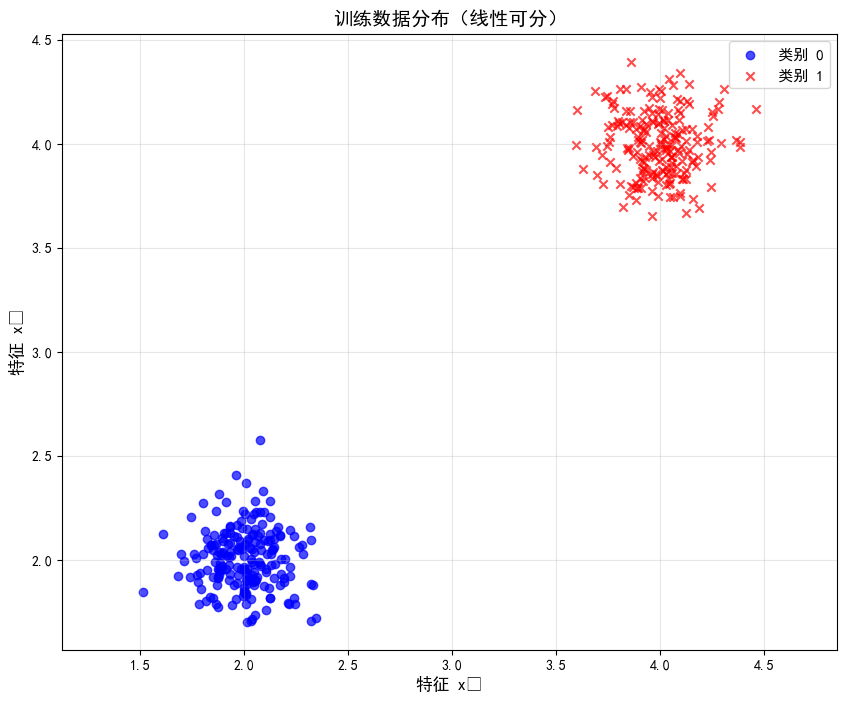

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
np.random.seed(42)

print("="*60)
print("二分类逻辑回归从零实现")
print("="*60)

# ========== 生成线性可分数据 ==========
def generate_linear_data(n_samples=200, noise=0.1):
    """
    生成线性可分的二分类数据
    类别0: 以 (2, 2) 为中心
    类别1: 以 (4, 4) 为中心
    """
    # 类别0
    x0 = np.random.randn(n_samples, 2) * noise + np.array([2, 2])
    y0 = np.zeros(n_samples)
    
    # 类别1
    x1 = np.random.randn(n_samples, 2) * noise + np.array([4, 4])
    y1 = np.ones(n_samples)
    
    # 合并数据
    X = np.vstack([x0, x1])
    y = np.hstack([y0, y1])
    
    return X, y

# 生成训练数据
X_train, y_train = generate_linear_data(n_samples=200, noise=0.15)

print(f"训练数据信息:")
print(f"特征维度: {X_train.shape[1]}")
print(f"样本数量: {X_train.shape[0]}")
print(f"类别分布: 类别0 = {sum(y_train==0)}, 类别1 = {sum(y_train==1)}")

# 可视化训练数据
plt.figure(figsize=(10, 8))
plt.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], 
            c='blue', marker='o', label='类别 0', alpha=0.7)
plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], 
            c='red', marker='x', label='类别 1', alpha=0.7)
plt.xlabel('特征 x₁', fontsize=12)
plt.ylabel('特征 x₂', fontsize=12)
plt.title('训练数据分布（线性可分）', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

测试数据信息:
样本数量: 200
类别分布: 类别0 = 100, 类别1 = 100


C:\Users\邓宇阳\AppData\Local\Temp\ipykernel_39356\2207365194.py:12: UserWarning: You passed a edgecolor/edgecolors ('red') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test[y_test==1, 0], X_test[y_test==1, 1],


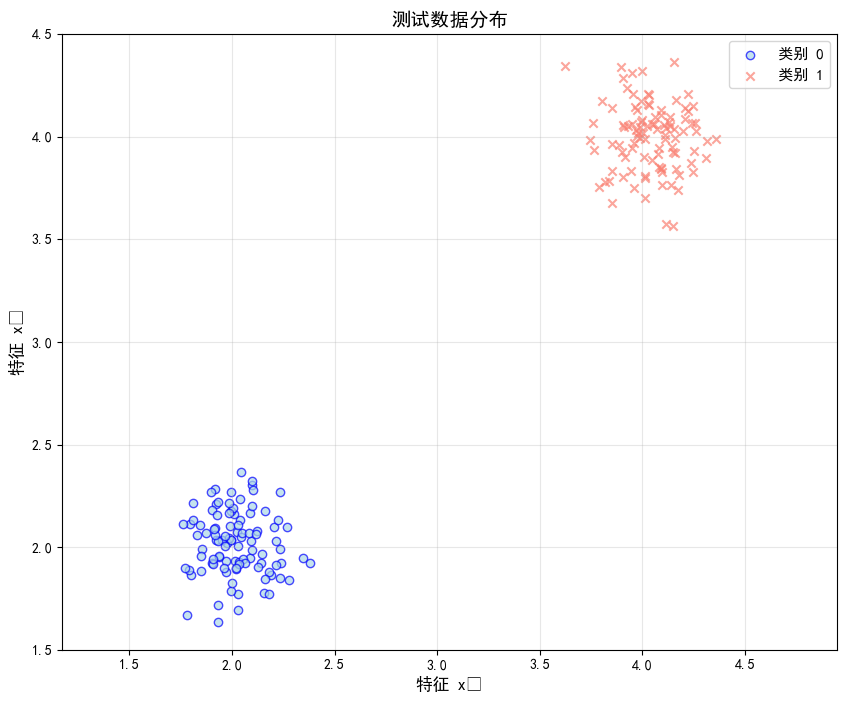

In [29]:
# 生成测试数据（新生成100个样本）
X_test, y_test = generate_linear_data(n_samples=100, noise=0.15)

print(f"测试数据信息:")
print(f"样本数量: {X_test.shape[0]}")
print(f"类别分布: 类别0 = {sum(y_test==0)}, 类别1 = {sum(y_test==1)}")

# 可视化测试数据
plt.figure(figsize=(10, 8))
plt.scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], 
            c='lightblue', marker='o', label='类别 0', alpha=0.7, edgecolors='blue')
plt.scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], 
            c='salmon', marker='x', label='类别 1', alpha=0.7, edgecolors='red')
plt.xlabel('特征 x₁', fontsize=12)
plt.ylabel('特征 x₂', fontsize=12)
plt.title('测试数据分布', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

In [30]:
class LogisticRegression:
    """从零实现的二分类逻辑回归"""
    
    def __init__(self, learning_rate=0.1, n_iterations=1000):
        """
        初始化参数
        learning_rate: 学习率
        n_iterations: 迭代次数
        """
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.W = None  # 权重
        self.b = None  # 偏置
        self.losses = []  # 记录损失历史
        
    def sigmoid(self, z):
        """
        Sigmoid 激活函数
        z: 线性输出 (n_samples,)
        返回: 概率值 (0, 1)
        """
        # 数值稳定性：限制 z 的范围
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    
    def binary_cross_entropy(self, y_pred, y_true):
        """
        二元交叉熵损失函数
        y_pred: 预测概率 (n_samples,)
        y_true: 真实标签 (n_samples,)
        返回: 平均损失
        """
        # 避免 log(0)
        eps = 1e-8
        y_pred = np.clip(y_pred, eps, 1 - eps)
        
        # 二元交叉熵公式
        loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
        return loss
    
    def compute_gradients(self, X, y_pred, y_true):
        """
        计算梯度
        X: 输入特征 (n_samples, n_features)
        y_pred: 预测概率 (n_samples,)
        y_true: 真实标签 (n_samples,)
        返回: dW, db
        """
        n_samples = X.shape[0]
        
        # 计算误差
        error = y_pred - y_true
        
        # 计算梯度
        dW = np.dot(X.T, error) / n_samples
        db = np.sum(error) / n_samples
        
        return dW, db
    
    def update_parameters(self, dW, db):
        """使用梯度下降更新参数"""
        self.W -= self.learning_rate * dW
        self.b -= self.learning_rate * db
    
    def forward(self, X):
        """
        前向传播
        X: 输入特征 (n_samples, n_features)
        返回: 预测概率 (n_samples,)
        """
        # 线性部分: z = X·W + b
        z = np.dot(X, self.W) + self.b
        # 激活函数
        return self.sigmoid(z)
    
    def train(self, X, y):
        """
        训练模型
        X: 训练特征 (n_samples, n_features)
        y: 训练标签 (n_samples,)
        """
        # 初始化参数
        n_samples, n_features = X.shape
        self.W = np.random.randn(n_features) * 0.01
        self.b = 0.0
        
        print(f"\n初始化参数:")
        print(f"W 形状: {self.W.shape}")
        print(f"b: {self.b}")
        print(f"学习率: {self.learning_rate}")
        print(f"迭代次数: {self.n_iterations}")
        
        print("\n" + "="*60)
        print("开始训练")
        print("="*60)
        
        for i in range(self.n_iterations):
            # 前向传播
            y_pred = self.forward(X)
            
            # 计算损失
            loss = self.binary_cross_entropy(y_pred, y)
            self.losses.append(loss)
            
            # 计算梯度
            dW, db = self.compute_gradients(X, y_pred, y)
            
            # 更新参数
            self.update_parameters(dW, db)
            
            # 打印进度
            if (i + 1) % 100 == 0:
                accuracy = self.accuracy(X, y)
                print(f"Iteration {i+1:4d}/{self.n_iterations} | "
                      f"Loss: {loss:.6f} | "
                      f"Accuracy: {accuracy:.4f} | "
                      f"W: [{self.W[0]:.4f}, {self.W[1]:.4f}] | "
                      f"b: {self.b:.4f}")
        
        print("训练完成！")
    
    def predict_proba(self, X):
        """预测概率"""
        return self.forward(X)
    
    def predict(self, X, threshold=0.5):
        """
        预测类别
        X: 输入特征
        threshold: 分类阈值
        返回: 预测类别 (0 或 1)
        """
        probabilities = self.predict_proba(X)
        return (probabilities >= threshold).astype(int)
    
    def accuracy(self, X, y):
        """计算准确率"""
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

# 创建模型
model = LogisticRegression(learning_rate=0.1, n_iterations=1000)

# 训练模型
model.train(X_train, y_train)


初始化参数:
W 形状: (2,)
b: 0.0
学习率: 0.1
迭代次数: 1000

开始训练
Iteration  100/1000 | Loss: 0.473176 | Accuracy: 0.9475 | W: [0.2995, 0.2908] | b: -1.2613
Iteration  200/1000 | Loss: 0.360411 | Accuracy: 1.0000 | W: [0.4643, 0.4530] | b: -2.2939
Iteration  300/1000 | Loss: 0.285755 | Accuracy: 1.0000 | W: [0.6001, 0.5868] | b: -3.1339
Iteration  400/1000 | Loss: 0.234195 | Accuracy: 1.0000 | W: [0.7139, 0.6988] | b: -3.8321
Iteration  500/1000 | Loss: 0.197102 | Accuracy: 1.0000 | W: [0.8111, 0.7943] | b: -4.4244
Iteration  600/1000 | Loss: 0.169443 | Accuracy: 1.0000 | W: [0.8953, 0.8770] | b: -4.9359
Iteration  700/1000 | Loss: 0.148179 | Accuracy: 1.0000 | W: [0.9695, 0.9497] | b: -5.3844
Iteration  800/1000 | Loss: 0.131405 | Accuracy: 1.0000 | W: [1.0356, 1.0144] | b: -5.7828
Iteration  900/1000 | Loss: 0.117882 | Accuracy: 1.0000 | W: [1.0950, 1.0726] | b: -6.1406
Iteration 1000/1000 | Loss: 0.106777 | Accuracy: 1.0000 | W: [1.1490, 1.1253] | b: -6.4648
训练完成！


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

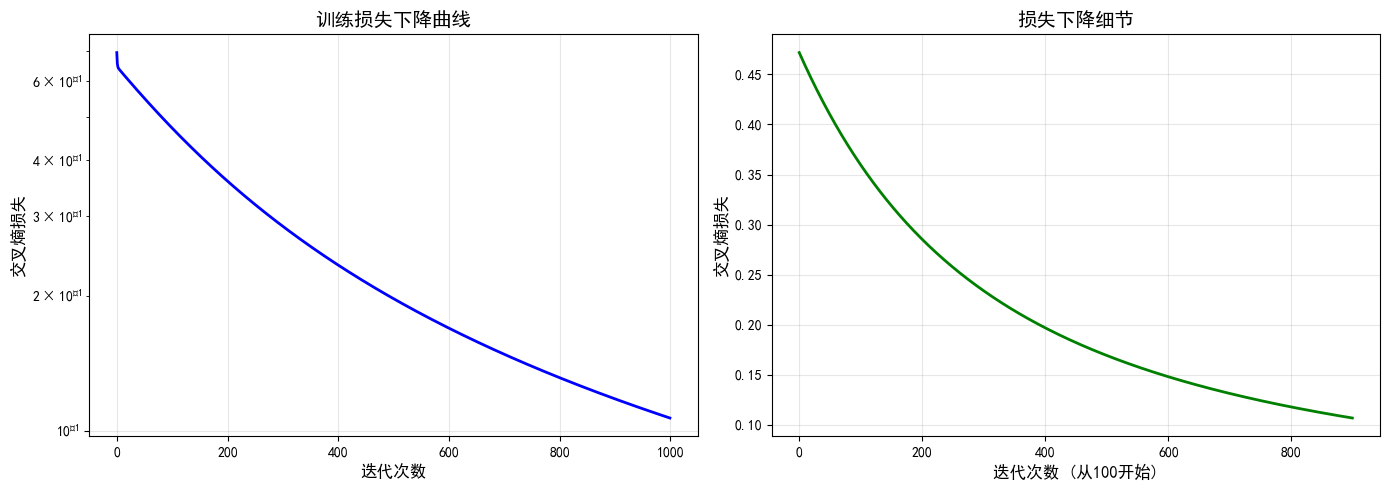


最终损失: 0.106777
初始损失: 0.694674
损失下降: 0.587897


In [31]:
# 绘制损失下降曲线
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 损失曲线
axes[0].plot(model.losses, 'b-', linewidth=2)
axes[0].set_xlabel('迭代次数', fontsize=12)
axes[0].set_ylabel('交叉熵损失', fontsize=12)
axes[0].set_title('训练损失下降曲线', fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')  # 对数坐标更清晰

# 损失变化（放大后100次迭代）
axes[1].plot(model.losses[100:], 'g-', linewidth=2)
axes[1].set_xlabel('迭代次数 (从100开始)', fontsize=12)
axes[1].set_ylabel('交叉熵损失', fontsize=12)
axes[1].set_title('损失下降细节', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n最终损失: {model.losses[-1]:.6f}")
print(f"初始损失: {model.losses[0]:.6f}")
print(f"损失下降: {model.losses[0] - model.losses[-1]:.6f}")

C:\Users\邓宇阳\AppData\Local\Temp\ipykernel_39356\79424563.py:24: UserWarning: You passed a edgecolor/edgecolors ('darkred') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X[y==1, 0], X[y==1, 1],
C:\Users\邓宇阳\AppData\Local\Temp\ipykernel_39356\79424563.py:40: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  plt.tight_layout()
C:\Users\邓宇阳\AppData\Local\Temp\ipykernel_39356\79424563.py:40: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  plt.tight_layout()


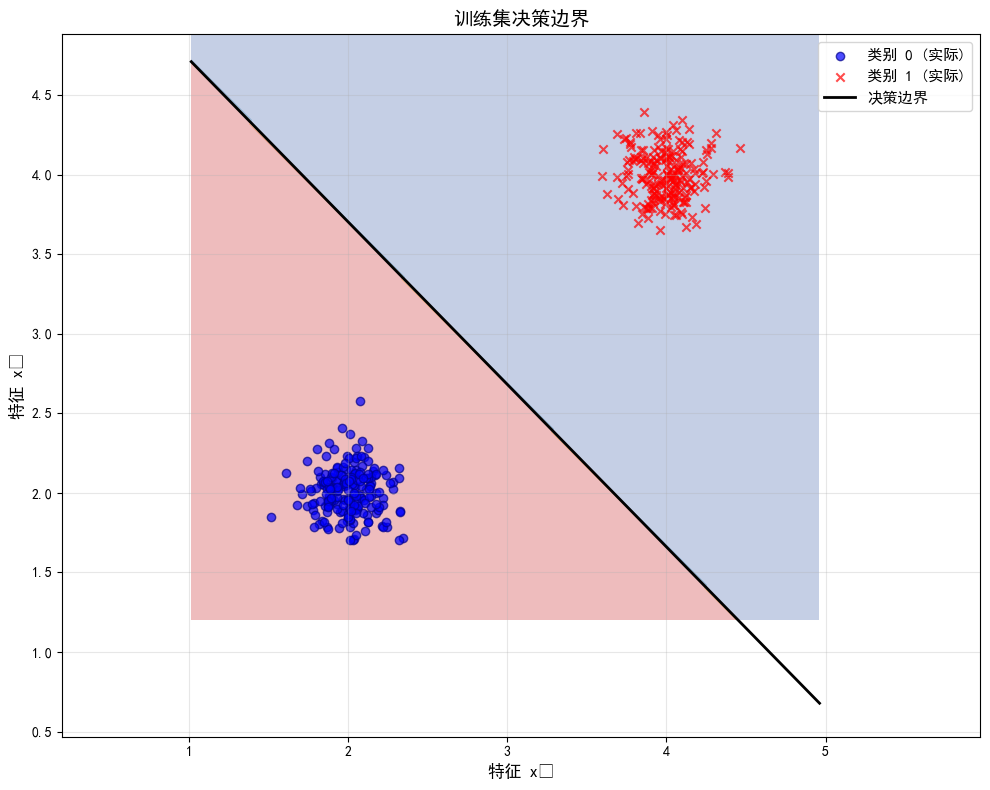

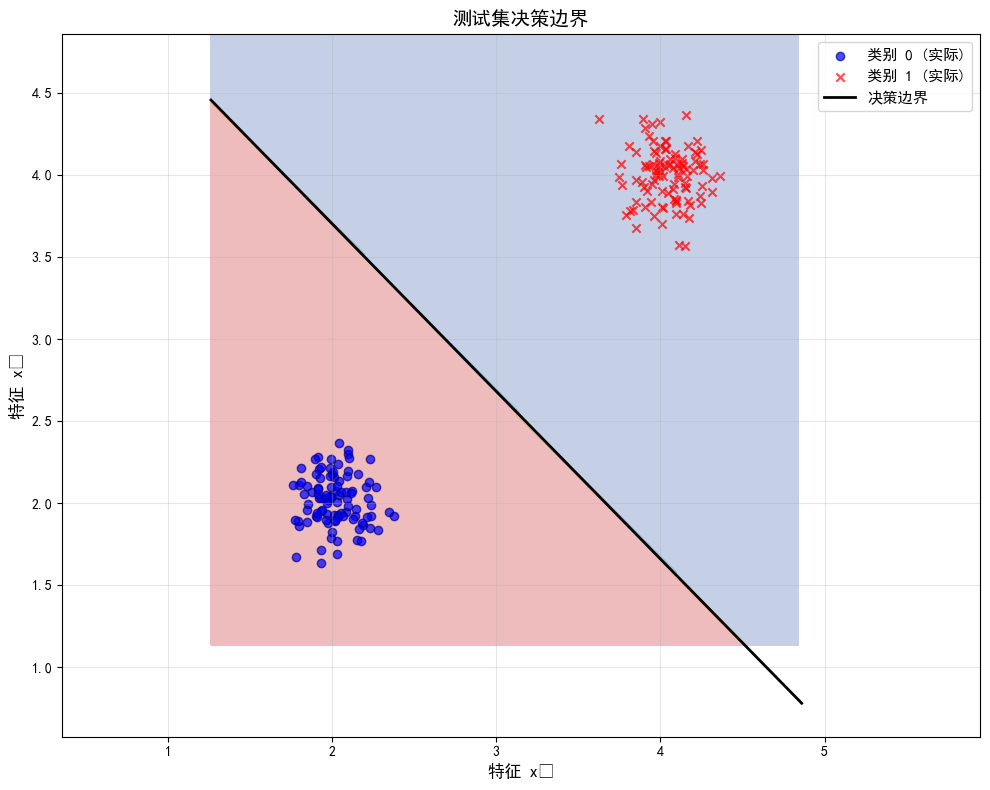

In [32]:
def plot_decision_boundary(model, X, y, title="决策边界"):
    """
    绘制决策边界
    """
    # 确定绘图范围
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    
    # 创建网格
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    # 预测网格点的类别
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # 绘制决策边界
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    
    # 绘制数据点
    plt.scatter(X[y==0, 0], X[y==0, 1], 
                c='blue', marker='o', label='类别 0 (实际)', alpha=0.7, edgecolors='darkblue')
    plt.scatter(X[y==1, 0], X[y==1, 1], 
                c='red', marker='x', label='类别 1 (实际)', alpha=0.7, edgecolors='darkred')
    
    # 绘制决策边界线（概率=0.5）
    # 计算决策边界方程: w0*x + w1*y + b = 0
    if model.W[1] != 0:
        x_boundary = np.linspace(x_min, x_max, 100)
        y_boundary = -(model.W[0] * x_boundary + model.b) / model.W[1]
        plt.plot(x_boundary, y_boundary, 'k-', linewidth=2, label='决策边界')
    
    plt.xlabel('特征 x₁', fontsize=12)
    plt.ylabel('特征 x₂', fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

# 绘制训练集的决策边界
plot_decision_boundary(model, X_train, y_train, "训练集决策边界")

# 绘制测试集的决策边界
plot_decision_boundary(model, X_test, y_test, "测试集决策边界")

In [33]:
# 在训练集和测试集上进行预测
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# 计算准确率
train_accuracy = model.accuracy(X_train, y_train)
test_accuracy = model.accuracy(X_test, y_test)

# 计算其他评估指标
from sklearn.metrics import confusion_matrix, classification_report

print("="*60)
print("模型评估结果")
print("="*60)

print(f"\n训练集准确率: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"测试集准确率: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")



模型评估结果

训练集准确率: 1.0000 (100.00%)
测试集准确率: 1.0000 (100.00%)
